Original Dataset Shape: (13320, 9)


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


Roll Number: 150096724005
First Name: Prince
First Letter: P
Bathroom Requirement: 5

Rows after location filter: 236
Rows after bathroom condition: 10

Fewer than 150 rows found.
Bathroom condition removed.

Final Personalized Dataset Shape: (236, 9)

========== DATA TYPES ==========
area_type        object
availability     object
location         object
size             object
society          object
total_sqft       object
bath            float64
balcony         float64
price           float64
dtype: object

========== MISSING VALUES ==========
area_type         0
availability      0
location          0
size              0
society         125
total_sqft        0
bath              0
balcony          10
price             0
dtype: int64

========== DUPLICATES ==========
Duplicate rows: 20

========== STATISTICAL SUMMARY ==========


,bath,balcony,price
count,236.000000,226.000000,236.000000
mean,2.411017,1.504425,100.182267
std,1.025487,0.865372,96.855243
min,1.000000,0.000000,20.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,1.000000,65.650000
75%,3.000000,2.000000,95.500000
max,8.000000,3.000000,600.000000



Column: price
Q1: 50.0
Q3: 95.5
IQR: 45.5
Lower Bound: -18.25
Upper Bound: 163.75
Number of Outliers: 33

Column: area
Q1: 1100.0
Q3: 1475.0
IQR: 375.0
Lower Bound: 537.5
Upper Bound: 2037.5
Number of Outliers: 25

Dataset shape after cleaning: (216, 12)

Remaining missing values:
location    0
area        0
BHK         0
bath        0
price       0
dtype: int64


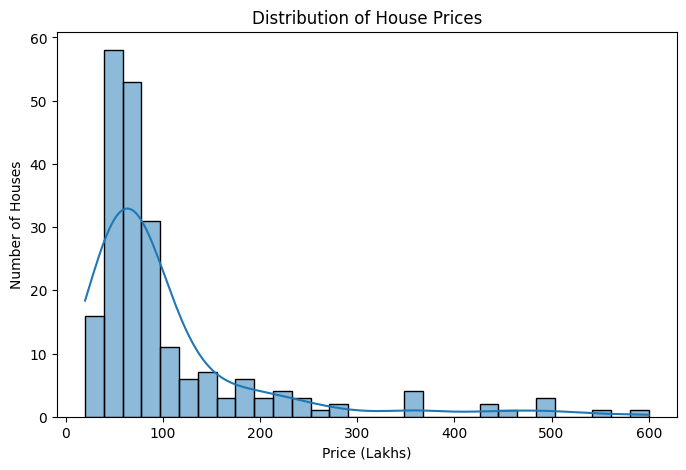

Insight:
House prices are right-skewed, with most houses having lower-to-medium prices and fewer houses having very high prices.


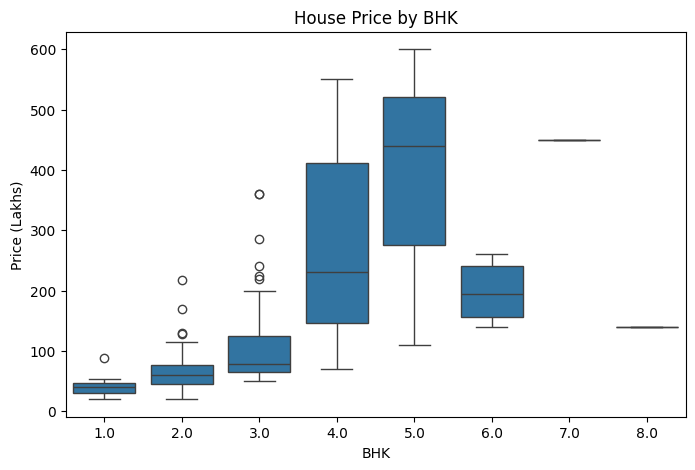

Insight:
Larger BHK houses generally have higher prices, although there is considerable variation within each BHK category.


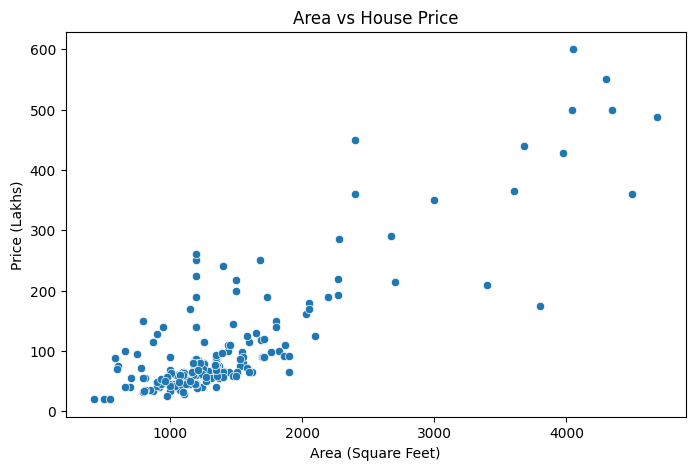

Insight:
There is a positive relationship between area and price. Larger houses generally tend to have higher prices.


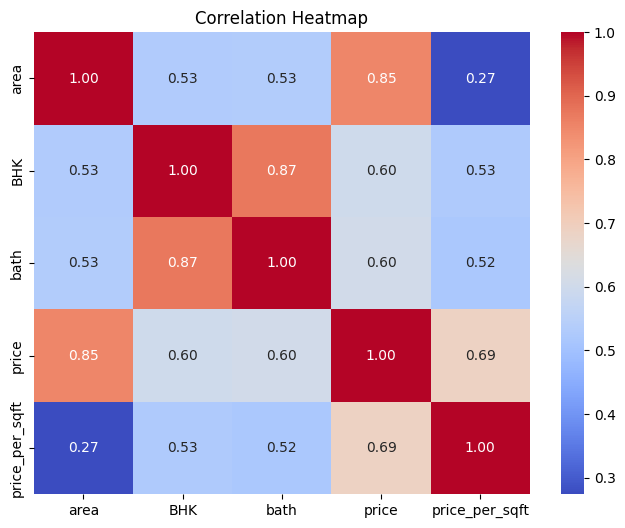

Insight:
Area, BHK and bathrooms show positive relationships with price. Area is one of the important numerical factors affecting house price.


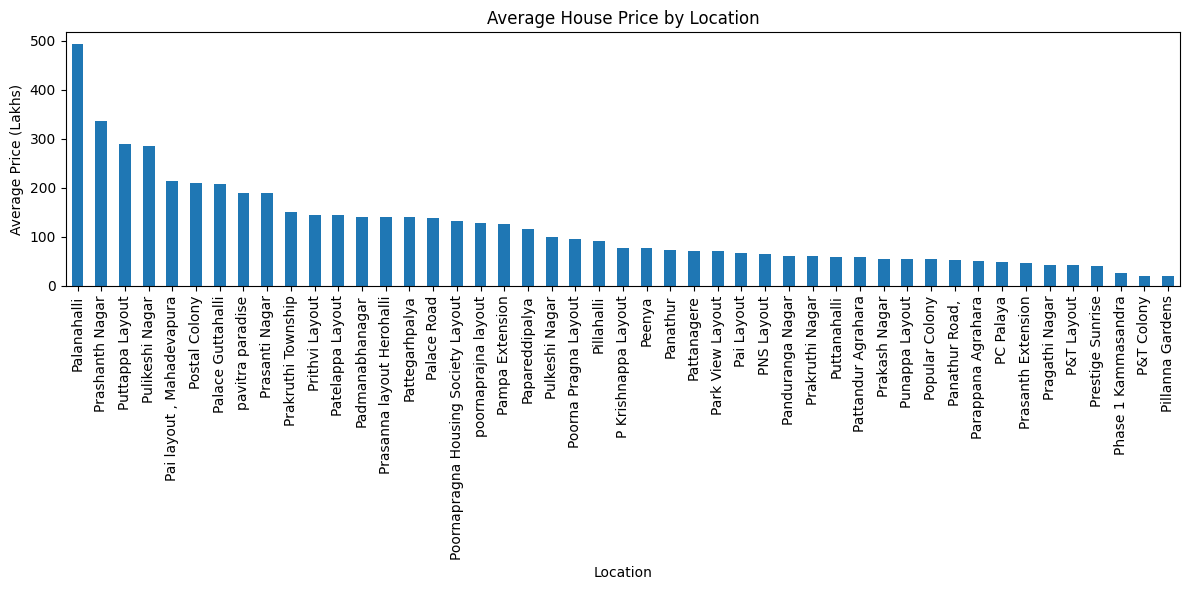

Insight:
Average prices vary considerably between locations, showing that location has an important effect on house prices.

Training samples: 172
Testing samples: 44

========== LINEAR REGRESSION RESULTS ==========
Train R²: 0.844
Test R²: 0.793
Test RMSE: 58.640

Rows after removing extreme outliers: 184

========== REFINED MODEL RESULTS ==========
Train R²: 0.667
Test R²: 0.485
Test RMSE: 19.950

========== PASS CONDITION ==========
PASS ✅
Baseline Test R² = 0.793


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


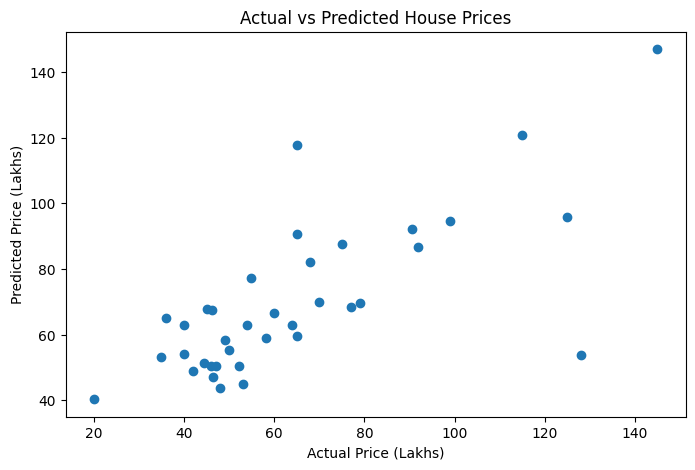


========== MODEL COMPARISON ==========
Baseline Model:
Train R² = 0.844
Test R² = 0.793
Test RMSE = 58.640

Refined Model:
Train R² = 0.667
Test R² = 0.485
Test RMSE = 19.950

========== FINAL SUMMARY ==========

The personalized dataset contains 216 houses
after filtering locations beginning with the letter P.

The bathroom condition was initially set to >= 5,
but it produced fewer than 150 rows, so the condition was
removed according to the assignment instructions.

Missing values were handled and total_sqft ranges were converted
into a single numeric area value.

A price_per_sqft feature was also created.

The analysis showed that area, BHK, bathrooms and location
affect house prices. Larger houses generally have higher prices,
while location creates significant differences in average price.

The Linear Regression model used area, BHK, bathrooms and
one-hot encoded location.

Baseline Model:
Train R² = 0.844
Test R² = 0.793
Test RMSE = 58.640

Refined Model:
Train R² = 0.667
Test R

In [9]:
# ============================================================
# MACHINE LEARNING FUNDAMENTALS
# Assignment 2: House Price Prediction
# Bengaluru Housing Data
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error


# ============================================================
# 2. LOAD DATASET
# ============================================================

df = pd.read_csv("Bengaluru_House_Data.csv")

print("Original Dataset Shape:", df.shape)

display(df.head())


# ============================================================
# 3. PERSONALIZE THE DATASET
# ============================================================

roll_number = 150096724005
first_name = "Prince"

# Last digit of roll number
last_digit = roll_number % 10

# First letter of name
first_letter = first_name[0].lower()

print("Roll Number:", roll_number)
print("First Name:", first_name)
print("First Letter:", first_letter.upper())
print("Bathroom Requirement:", last_digit)


# Keep locations starting with the first letter
location_filtered = df[
    df["location"].fillna("").str.strip().str.lower().str.startswith(first_letter)
].copy()

print(
    "\nRows after location filter:",
    len(location_filtered)
)


# Apply bathroom condition
filtered_df = location_filtered[
    location_filtered["bath"] >= last_digit
].copy()

print(
    "Rows after bathroom condition:",
    len(filtered_df)
)


# If fewer than 150 rows, remove bathroom condition
if len(filtered_df) < 150:

    filtered_df = location_filtered.copy()

    print("\nFewer than 150 rows found.")
    print("Bathroom condition removed.")

else:

    print("\n150 or more rows found.")
    print("Bathroom condition retained.")


print(
    "\nFinal Personalized Dataset Shape:",
    filtered_df.shape
)


# ============================================================
# 4. BASIC EDA
# ============================================================

print("\n========== DATA TYPES ==========")

print(filtered_df.dtypes)


print("\n========== MISSING VALUES ==========")

print(filtered_df.isnull().sum())


print("\n========== DUPLICATES ==========")

print(
    "Duplicate rows:",
    filtered_df.duplicated().sum()
)


print("\n========== STATISTICAL SUMMARY ==========")

display(filtered_df.describe())


# ============================================================
# 5. OUTLIER CHECK
# ============================================================

# First create numeric area column for outlier analysis

def convert_sqft(value):

    value = str(value)

    if "-" in value:

        parts = value.split("-")

        try:
            return (
                float(parts[0]) +
                float(parts[1])
            ) / 2

        except:
            return np.nan

    try:
        return float(value)

    except:
        return np.nan


filtered_df["area"] = filtered_df["total_sqft"].apply(
    convert_sqft
)


def check_outliers(data, column):

    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]

    print("\nColumn:", column)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Number of Outliers:", len(outliers))

    return outliers


price_outliers = check_outliers(
    filtered_df,
    "price"
)

area_outliers = check_outliers(
    filtered_df,
    "area"
)


# ============================================================
# 6. CLEAN THE DATA
# ============================================================

# Convert BHK from size column
filtered_df["BHK"] = filtered_df["size"].str.extract(
    r"(\d+)"
).astype(float)


# Fill missing numerical values
filtered_df["BHK"] = filtered_df["BHK"].fillna(
    filtered_df["BHK"].median()
)

filtered_df["bath"] = filtered_df["bath"].fillna(
    filtered_df["bath"].median()
)

filtered_df["area"] = filtered_df["area"].fillna(
    filtered_df["area"].median()
)


# Fill missing location
filtered_df["location"] = filtered_df["location"].fillna(
    filtered_df["location"].mode()[0]
)


# Remove duplicate rows
filtered_df = filtered_df.drop_duplicates().copy()


# Create price per square foot
filtered_df["price_per_sqft"] = (
    filtered_df["price"] * 100000 /
    filtered_df["area"]
)


print(
    "\nDataset shape after cleaning:",
    filtered_df.shape
)

print(
    "\nRemaining missing values:"
)

print(
    filtered_df[
        ["location", "area", "BHK", "bath", "price"]
    ].isnull().sum()
)


# ============================================================
# 7. PLOT 1 - PRICE DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

sns.histplot(
    filtered_df["price"],
    bins=30,
    kde=True
)

plt.title("Distribution of House Prices")
plt.xlabel("Price (Lakhs)")
plt.ylabel("Number of Houses")

plt.show()

print("Insight:")
print(
    "House prices are right-skewed, with most houses having "
    "lower-to-medium prices and fewer houses having very high prices."
)


# ============================================================
# 8. PLOT 2 - PRICE BY BHK
# ============================================================

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=filtered_df,
    x="BHK",
    y="price"
)

plt.title("House Price by BHK")
plt.xlabel("BHK")
plt.ylabel("Price (Lakhs)")

plt.show()

print("Insight:")
print(
    "Larger BHK houses generally have higher prices, although "
    "there is considerable variation within each BHK category."
)


# ============================================================
# 9. PLOT 3 - AREA VS PRICE
# ============================================================

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=filtered_df,
    x="area",
    y="price"
)

plt.title("Area vs House Price")
plt.xlabel("Area (Square Feet)")
plt.ylabel("Price (Lakhs)")

plt.show()

print("Insight:")
print(
    "There is a positive relationship between area and price. "
    "Larger houses generally tend to have higher prices."
)


# ============================================================
# 10. PLOT 4 - CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(8, 6))

numeric_columns = [
    "area",
    "BHK",
    "bath",
    "price",
    "price_per_sqft"
]

correlation_matrix = filtered_df[
    numeric_columns
].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

print("Insight:")
print(
    "Area, BHK and bathrooms show positive relationships with price. "
    "Area is one of the important numerical factors affecting house price."
)


# ============================================================
# 11. PLOT 5 - AVERAGE PRICE BY LOCATION
# ============================================================

location_average = filtered_df.groupby(
    "location"
)["price"].mean().sort_values(
    ascending=False
)

plt.figure(figsize=(12, 6))

location_average.plot(
    kind="bar"
)

plt.title("Average House Price by Location")
plt.xlabel("Location")
plt.ylabel("Average Price (Lakhs)")
plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

print("Insight:")
print(
    "Average prices vary considerably between locations, showing "
    "that location has an important effect on house prices."
)


# ============================================================
# 12. PREPARE DATA FOR LINEAR REGRESSION
# ============================================================

features = [
    "area",
    "BHK",
    "bath",
    "location"
]

X = filtered_df[features]

y = filtered_df["price"]


# ============================================================
# 13. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


# ============================================================
# 14. ENCODE LOCATION
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "location",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            ["location"]
        )
    ],
    remainder="passthrough"
)


# ============================================================
# 15. LINEAR REGRESSION MODEL
# ============================================================

model = Pipeline(
    steps=[
        ("encoding", preprocessor),
        ("regression", LinearRegression())
    ]
)


# Train model
model.fit(
    X_train,
    y_train
)


# Predictions
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)


# ============================================================
# 16. MODEL EVALUATION
# ============================================================

train_r2 = r2_score(
    y_train,
    train_pred
)

test_r2 = r2_score(
    y_test,
    test_pred
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        test_pred
    )
)


print("\n========== LINEAR REGRESSION RESULTS ==========")

print(
    f"Train R²: {train_r2:.3f}"
)

print(
    f"Test R²: {test_r2:.3f}"
)

print(
    f"Test RMSE: {test_rmse:.3f}"
)


# ============================================================
# 17. REMOVE EXTREME OUTLIERS
# ============================================================

# Remove extreme price and area values using IQR

price_Q1 = filtered_df["price"].quantile(0.25)
price_Q3 = filtered_df["price"].quantile(0.75)

price_IQR = price_Q3 - price_Q1

price_lower = price_Q1 - 1.5 * price_IQR
price_upper = price_Q3 + 1.5 * price_IQR


area_Q1 = filtered_df["area"].quantile(0.25)
area_Q3 = filtered_df["area"].quantile(0.75)

area_IQR = area_Q3 - area_Q1

area_lower = area_Q1 - 1.5 * area_IQR
area_upper = area_Q3 + 1.5 * area_IQR


refined_df = filtered_df[
    (filtered_df["price"] >= price_lower) &
    (filtered_df["price"] <= price_upper) &
    (filtered_df["area"] >= area_lower) &
    (filtered_df["area"] <= area_upper)
].copy()


print(
    "\nRows after removing extreme outliers:",
    len(refined_df)
)


# ============================================================
# 18. REFINED MODEL WITH LOG-TRANSFORMED PRICE
# ============================================================

X_refined = refined_df[
    ["area", "BHK", "bath", "location"]
]

y_refined = np.log1p(
    refined_df["price"]
)


X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_refined,
    y_refined,
    test_size=0.20,
    random_state=42
)


refined_model = Pipeline(
    steps=[
        ("encoding", preprocessor),
        ("regression", LinearRegression())
    ]
)


refined_model.fit(
    X_train_r,
    y_train_r
)


# Predictions
train_log_pred = refined_model.predict(
    X_train_r
)

test_log_pred = refined_model.predict(
    X_test_r
)


# Convert back to price
train_price_pred = np.expm1(
    train_log_pred
)

test_price_pred = np.expm1(
    test_log_pred
)

actual_train_price = np.expm1(
    y_train_r
)

actual_test_price = np.expm1(
    y_test_r
)


# ============================================================
# 19. REFINED MODEL EVALUATION
# ============================================================

refined_train_r2 = r2_score(
    actual_train_price,
    train_price_pred
)

refined_test_r2 = r2_score(
    actual_test_price,
    test_price_pred
)

refined_rmse = np.sqrt(
    mean_squared_error(
        actual_test_price,
        test_price_pred
    )
)


print("\n========== REFINED MODEL RESULTS ==========")

print(
    f"Train R²: {refined_train_r2:.3f}"
)

print(
    f"Test R²: {refined_test_r2:.3f}"
)

print(
    f"Test RMSE: {refined_rmse:.3f}"
)


# ============================================================
# 20. PASS CONDITION
# ============================================================

print("\n========== PASS CONDITION ==========")

if test_r2 >= 0.75:

    print("PASS ✅")
    print(
        f"Baseline Test R² = {test_r2:.3f}"
    )

elif refined_test_r2 >= 0.75:

    print("PASS ✅")
    print(
        f"Refined Test R² = {refined_test_r2:.3f}"
    )

else:

    print("Pass condition not achieved.")
    print("More feature refinement may be required.")


# ============================================================
# 21. ACTUAL VS PREDICTED PRICE
# ============================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    actual_test_price,
    test_price_pred
)

plt.xlabel("Actual Price (Lakhs)")
plt.ylabel("Predicted Price (Lakhs)")
plt.title("Actual vs Predicted House Prices")

plt.show()


# ============================================================
# 22. MODEL COMPARISON
# ============================================================

print("\n========== MODEL COMPARISON ==========")

print(
    f"Baseline Model:"
)

print(
    f"Train R² = {train_r2:.3f}"
)

print(
    f"Test R² = {test_r2:.3f}"
)

print(
    f"Test RMSE = {test_rmse:.3f}"
)

print()

print(
    f"Refined Model:"
)

print(
    f"Train R² = {refined_train_r2:.3f}"
)

print(
    f"Test R² = {refined_test_r2:.3f}"
)

print(
    f"Test RMSE = {refined_rmse:.3f}"
)


# ============================================================
# 23. FINAL SUMMARY
# ============================================================

print("\n========== FINAL SUMMARY ==========")

print(
    f"""
The personalized dataset contains {len(filtered_df)} houses
after filtering locations beginning with the letter P.

The bathroom condition was initially set to >= {last_digit},
but it produced fewer than 150 rows, so the condition was
removed according to the assignment instructions.

Missing values were handled and total_sqft ranges were converted
into a single numeric area value.

A price_per_sqft feature was also created.

The analysis showed that area, BHK, bathrooms and location
affect house prices. Larger houses generally have higher prices,
while location creates significant differences in average price.

The Linear Regression model used area, BHK, bathrooms and
one-hot encoded location.

Baseline Model:
Train R² = {train_r2:.3f}
Test R² = {test_r2:.3f}
Test RMSE = {test_rmse:.3f}

Refined Model:
Train R² = {refined_train_r2:.3f}
Test R² = {refined_test_r2:.3f}
Test RMSE = {refined_rmse:.3f}
"""
)